In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.concat(
	[pd.read_csv(p) for p in Path("logs/reruns").glob("*csv")],
	ignore_index=True,
)
print(df.shape)
df.sample(5)

(367, 22)


,timestamp,run_name,step,train_loss,val_loss,loss_gap,val_perplexity,tokens_seen,tokens_per_second,step_time_ms,grad_norm,mps_allocated_mb,mps_driver_mb,parameters,parameter_memory_mb,device,batch_size,block_size,embd_dim,n_head,n_layer,learning_rate
295,2026-07-02T22:37:24,run_20260702_223322,2500,1.919086,2.038833,0.119746,7.681637,320000,1448.973334,88.338410,1.425190,78.824219,122.937500,4780096,18.234619,mps,4,32,256,4,6,0.001
173,2026-07-02T20:18:10,run_20260702_201625,2750,1.830790,1.926385,0.095595,6.864652,352000,4023.520876,31.812933,1.279750,26.719727,58.937500,1621056,6.183838,mps,4,32,256,4,2,0.001
90,2026-07-02T21:36:57,run_20260702_213521,2000,1.918282,2.013859,0.095577,7.492173,256000,2970.068093,43.096655,1.201843,50.598877,90.953125,3200576,12.209229,mps,4,32,256,2,4,0.001
5,2026-07-02T23:20:16,run_20260702_231927,1250,2.013281,2.052786,0.039505,7.789576,160000,3911.491080,32.724094,1.465031,26.719727,58.937500,1621056,6.183838,mps,4,32,256,4,2,0.001
229,2026-07-02T22:25:28,run_20260702_222029,6500,1.690626,1.798726,0.108100,6.041945,832000,3133.783187,40.845200,1.185118,50.598877,90.953125,3200576,12.209229,mps,4,32,256,2,4,0.001


label each run by config - for readability

In [3]:
df["cfg"] = (
	"block=" + df["block_size"].astype(str)
    + ", embd=" + df["embd_dim"].astype(str)
    + ", layers=" + df["n_layer"].astype(str)
    + ", heads=" + df["n_head"].astype(str)
)

df.cfg.unique()

<ArrowStringArray>
['block=32, embd=256, layers=2, heads=4',
 'block=32, embd=256, layers=4, heads=2',
 'block=32, embd=256, layers=6, heads=4']
Length: 3, dtype: str

## summary table

we want to answer:
- which model trained better and did it overfit?
- which model trained faster / used resources more efficiently?

In [15]:
run_summary = (
	df.sort_values("tokens_seen")
	.groupby(["run_name", "cfg"])
	.agg(
		best_val_loss=("val_loss", "min"),
		final_val_loss=("val_loss", "last"),
		final_train_loss=("train_loss", "last"),
		final_loss_gap=("loss_gap", "last"),
		final_val_perplexity=("val_perplexity", "last"),	# optional: just more a more interpretable version of val loss

		max_tokens_seen=("tokens_seen", "max"),
		median_tokens_per_s=("tokens_per_second", "median"),

		parameters=("parameters", "first"),		# comparing model sizes
		parameter_memory_mb=("parameter_memory_mb", "first"),
		max_mps_allocated_mb=("mps_allocated_mb", "max")
	)
	.reset_index()
	.sort_values("best_val_loss")
)

run_summary

,run_name,cfg,best_val_loss,final_val_loss,final_train_loss,final_loss_gap,final_val_perplexity,max_tokens_seen,median_tokens_per_s,parameters,parameter_memory_mb,max_mps_allocated_mb
8,run_20260702_232542,"block=32, embd=256, layers=2, heads=4",1.685487,1.685487,1.582722,0.102765,5.395075,1280000,3930.349393,1621056,6.183838,29.401367
0,run_20260702_201625,"block=32, embd=256, layers=2, heads=4",1.686999,1.686999,1.577379,0.109620,5.403241,1280000,3948.685436,1621056,6.183838,26.719727
7,run_20260702_231927,"block=32, embd=256, layers=2, heads=4",1.693718,1.693718,1.583865,0.109853,5.439669,1280000,3961.564225,1621056,6.183838,29.401367
2,run_20260702_204606,"block=32, embd=256, layers=4, heads=2",1.732472,1.753138,1.614611,0.138527,5.772686,1280000,3152.013703,3200576,12.209229,55.698975
4,run_20260702_222029,"block=32, embd=256, layers=4, heads=2",1.733370,1.764178,1.624292,0.139886,5.836772,1280000,3118.770225,3200576,12.209229,55.698975
5,run_20260702_223322,"block=32, embd=256, layers=6, heads=4",1.743295,1.765621,1.640220,0.125401,5.845198,1280000,1451.761238,4780096,18.234619,85.302734
3,run_20260702_213521,"block=32, embd=256, layers=4, heads=2",1.744574,1.772664,1.634806,0.137859,5.886517,1280000,2970.068093,3200576,12.209229,55.698975
6,run_20260702_230216,"block=32, embd=256, layers=6, heads=4",1.746636,1.771787,1.640020,0.131768,5.881356,1280000,1451.404299,4780096,18.234619,85.302734
1,run_20260702_202307,"block=32, embd=256, layers=6, heads=4",1.753261,1.762096,1.641248,0.120848,5.824635,1280000,1375.570783,4780096,18.234619,85.302734


In [16]:
cfg_summary = (
	run_summary.groupby(["cfg"])
	.agg(
		mean_best_val_loss=("best_val_loss", "mean"),
		mean_final_val_loss=("final_val_loss", "mean"),

		median_tokens_per_s=("median_tokens_per_s", "median"),
		parameters=("parameters", "first"),
	)
)

cfg_summary

,mean_best_val_loss,mean_final_val_loss,median_tokens_per_s,parameters
cfg,,,,
"block=32, embd=256, layers=2, heads=4",1.688735,1.688735,3948.685436,1621056
"block=32, embd=256, layers=4, heads=2",1.736805,1.763327,3118.770225,3200576
"block=32, embd=256, layers=6, heads=4",1.747731,1.766501,1451.404299,4780096


`L=2, H=4` wins on:
- lowest mean final validation loss
- lowest mean best validation loss
- smallest model
- highest throughput
- all three runs individually beating the other configs

so let's just check it's not overfit

In [27]:
%matplotlib widget

In [37]:
import numpy as np
def plot_train_val_by_run(cfg_df: pd.DataFrame, title: str) -> None:
	plt.figure(figsize=(10, 6))

	run_name = df.run_name.unique()
	colors = dict(zip(run_name, plt.cm.tab10.colors[:len(run_name)]))

	for run_name, g in cfg_df.groupby("run_name"):
		g = g.sort_values("tokens_seen")

		plt.plot(
            g["tokens_seen"],
            np.log(g["train_loss"]),
            alpha=0.35,
			color=colors[run_name],
			linewidth=1.5,
            label=f"{run_name} train",
        )
		plt.plot(
            g["tokens_seen"],
            np.log(g["val_loss"]),
            alpha=0.35,
			color=colors[run_name],
            linewidth=1.5,
            linestyle="--",
            label=f"{run_name} val",
        )

	plt.xlabel("Tokens seen")
	plt.ylabel("log(Loss)")
	plt.title(title)
	plt.grid(True, alpha=0.3)
	plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
	plt.tight_layout()
	plt.show()

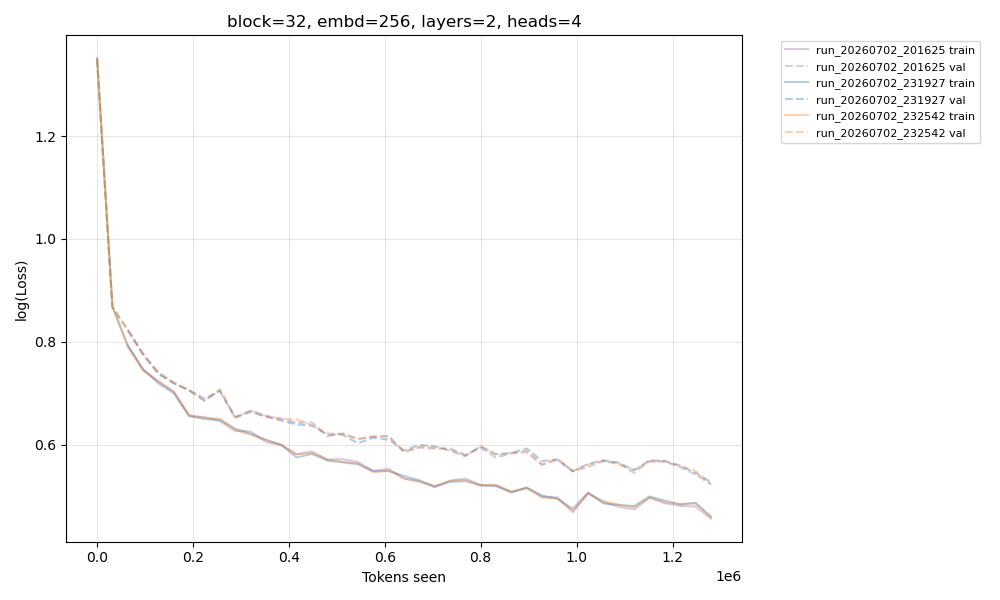

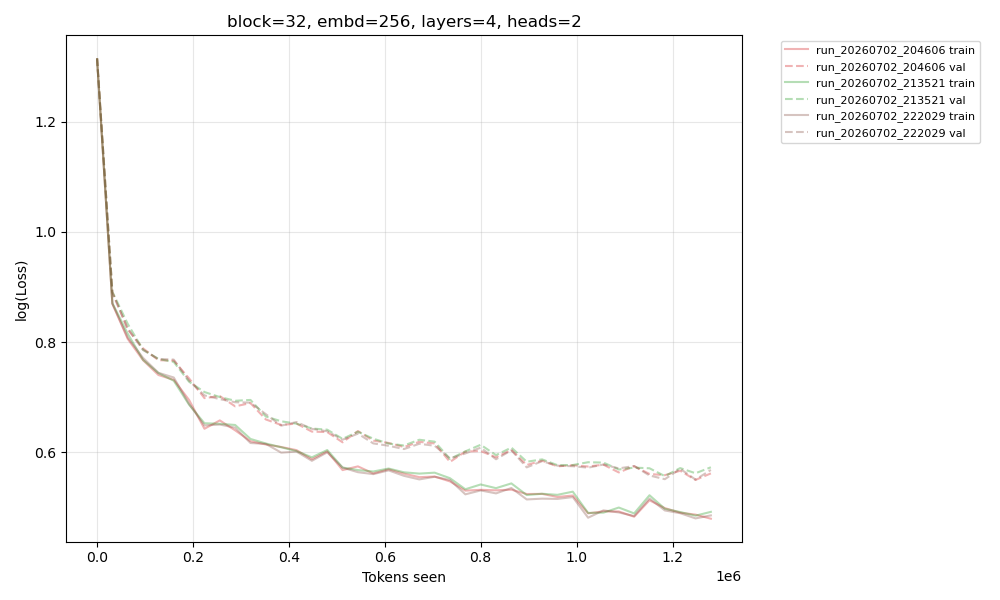

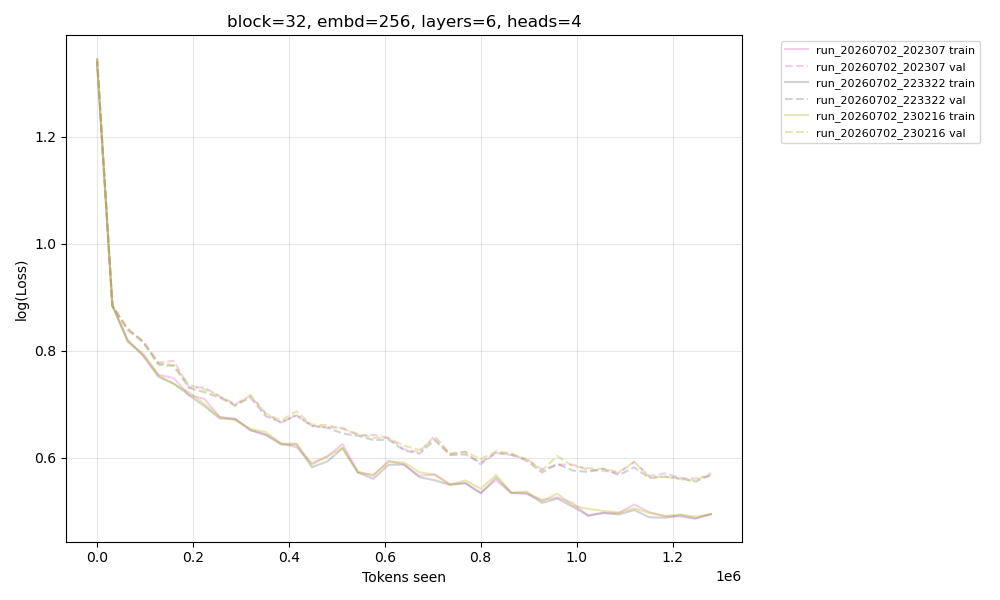

In [38]:
for cfg, cfg_df in df.groupby("cfg"):
    plot_train_val_by_run(cfg_df, cfg)